In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from pyod.models.iforest import IForest
from pyod.models.dif import DIF
from pyod.models.loda import LODA
from numpy.random import multivariate_normal

# Ex 1

In [74]:
x, y = make_blobs(n_samples=500, n_features=2, random_state=42)

n_bins = 50

vectors = multivariate_normal((0, 0), [[1, 0], [0, 1]], size=5)
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)

projected_values = [x @ p for p in vectors]

print(min([min(a) for a in projected_values]))
print(min([max(a) for a in projected_values]))

hist_1, bin_edg_1 = np.histogram(projected_values[0], bins = n_bins, range=(-50, 10))
hist_2, bin_edg_2 = np.histogram(projected_values[1], bins = n_bins, range=(-50, 10))
hist_3, bin_edg_3 = np.histogram(projected_values[2], bins = n_bins, range=(-50, 10))
hist_4, bin_edg_4 = np.histogram(projected_values[3], bins = n_bins, range=(-50, 10))
hist_5, bin_edg_5 = np.histogram(projected_values[4], bins = n_bins, range=(-50, 10))


-11.711273214690786
4.8955806923952085


In [75]:
prob_hist_1 = hist_1 / np.sum(hist_1)
prob_hist_2 = hist_2 / np.sum(hist_2)
prob_hist_3 = hist_3 / np.sum(hist_3)
prob_hist_4 = hist_4 / np.sum(hist_4)
prob_hist_5 = hist_5 / np.sum(hist_5)

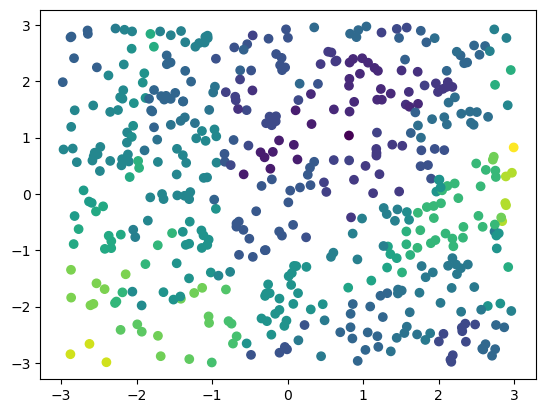

In [76]:
x_test = np.random.uniform(-3, 3, (500, 2))
projected_test_values = [x_test @ p for p in vectors]

test_scores = np.zeros(len(x_test))

for i in range(len(x_test)):
# for i in range(1):
    
    bin_index = np.digitize(projected_test_values[0][i], bin_edg_1) - 1
    bin_index = np.clip(bin_index, 0, n_bins - 1)
    p1 = prob_hist_1[bin_index]

    bin_index = np.digitize(projected_test_values[1][i], bin_edg_1) - 1
    bin_index = np.clip(bin_index, 0, n_bins - 1)
    p2 = prob_hist_2[bin_index]

    bin_index = np.digitize(projected_test_values[2][i], bin_edg_1) - 1
    bin_index = np.clip(bin_index, 0, n_bins - 1)
    p3 = prob_hist_3[bin_index]

    bin_index = np.digitize(projected_test_values[3][i], bin_edg_1) - 1
    bin_index = np.clip(bin_index, 0, n_bins - 1)
    p4 = prob_hist_4[bin_index]

    bin_index = np.digitize(projected_test_values[4][i], bin_edg_1) - 1
    bin_index = np.clip(bin_index, 0, n_bins - 1)
    p5 = prob_hist_5[bin_index]

    test_scores[i] = np.mean([p1, p2, p3, p4, p5])


plt.scatter(x_test[:,0], x_test[:,1], c=test_scores, cmap='viridis')
plt.show()

# Ex 2

In [12]:
x, y = make_blobs(n_samples=1000, n_features=2, centers=[(10, 0), (0, 10)], random_state=42)

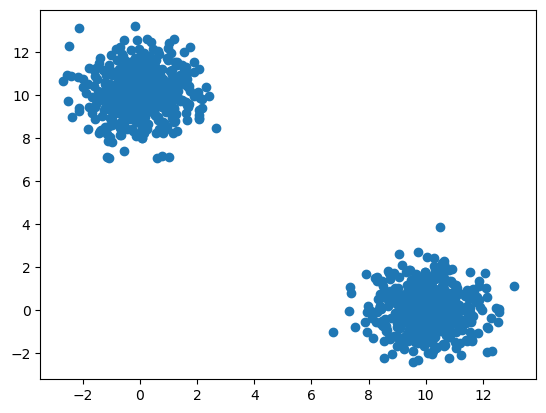

In [13]:
plt.scatter(x[:,0], x[:,1])

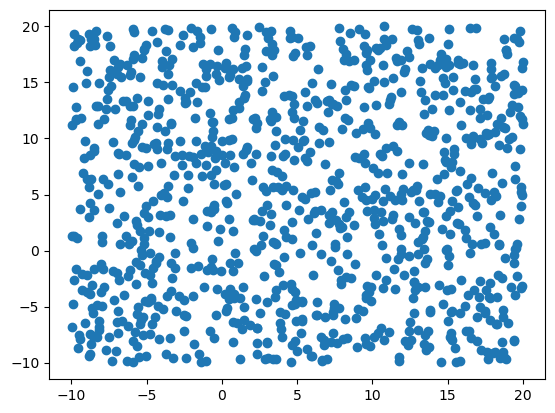

In [20]:
test_data = np.random.uniform(-10, 20, (1000, 2))
plt.scatter(test_data[:,0], test_data[:,1])

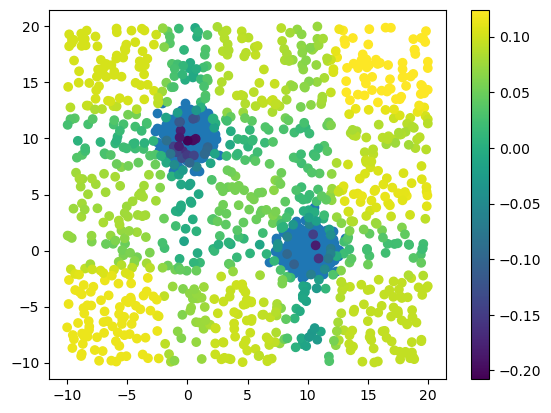

In [54]:
iforest_model = IForest(contamination=0.02)
iforest_model.fit(x)
iforest_scores = iforest_model.decision_function(test_data)

plt.scatter(x[:,0], x[:,1])
plt.scatter(test_data[:,0], test_data[:,1], c=iforest_scores, cmap='viridis')
plt.colorbar()
plt.show()

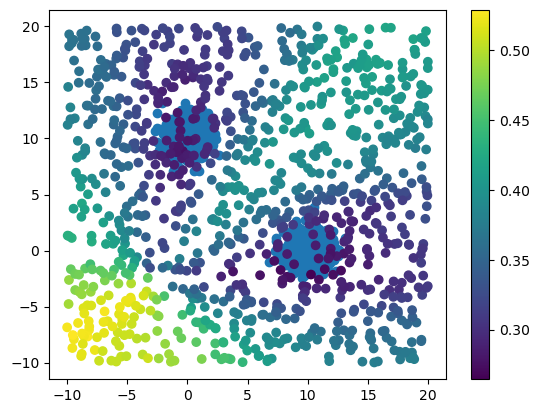

In [55]:
dif_model = DIF(contamination=0.02)
dif_model.fit(x)
dif_scores = dif_model.decision_function(test_data)

plt.scatter(x[:,0], x[:,1])
plt.scatter(test_data[:,0], test_data[:,1], c=dif_scores, cmap='viridis')
plt.colorbar()
plt.show()

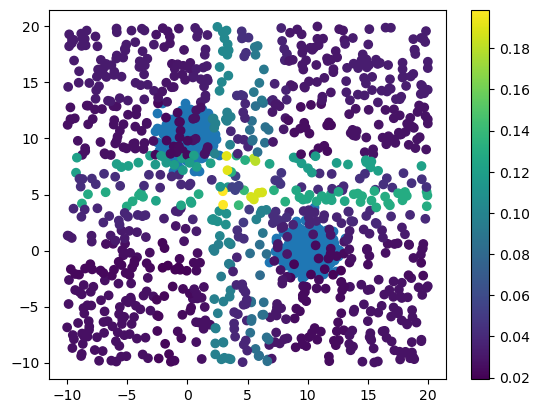

In [56]:
loda_model = LODA(contamination=0.02)
loda_model.fit(x)
loda_scores = loda_model.decision_function(test_data)

plt.scatter(x[:,0], x[:,1])
plt.scatter(test_data[:,0], test_data[:,1], c=loda_scores, cmap='viridis')
plt.colorbar()
plt.show()

[]

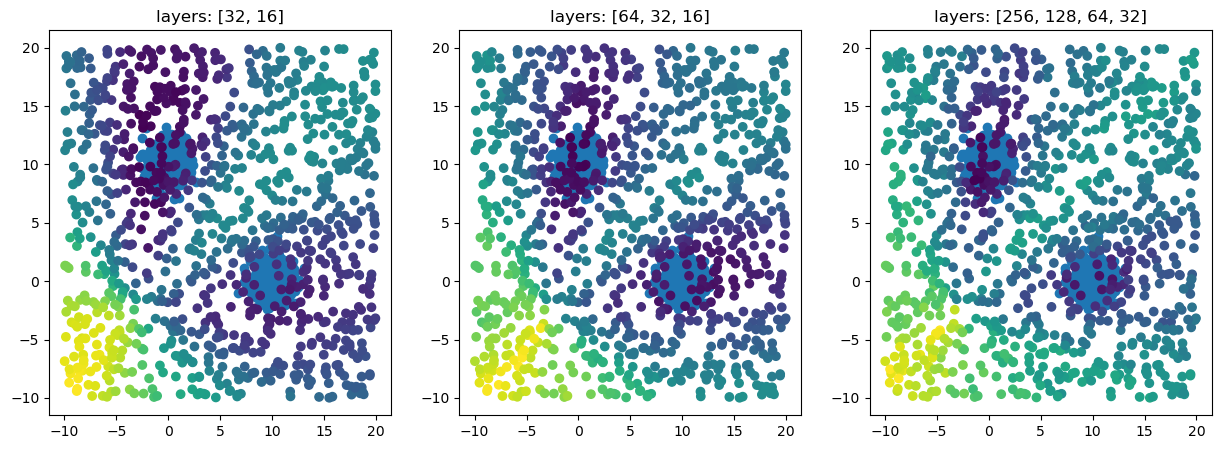

In [70]:
def compute_dif_scores(x, test_data, hidden_layers):
    dif_model = DIF(contamination=0.02, hidden_neurons=hidden_layers)
    dif_model.fit(x)
    dif_scores = dif_model.decision_function(test_data)
    return dif_scores


layers = [[32, 16], [64, 32, 16], [256, 128, 64, 32]]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    scores = compute_dif_scores(x, test_data, layers[i])

    axes[i].scatter(x[:, 0], x[:, 1])
    axes[i].scatter(test_data[:, 0], test_data[:, 1], c=scores, cmap='viridis')
    axes[i].set_title(f"layers: {layers[i]}")
    
plt.plot()

[]

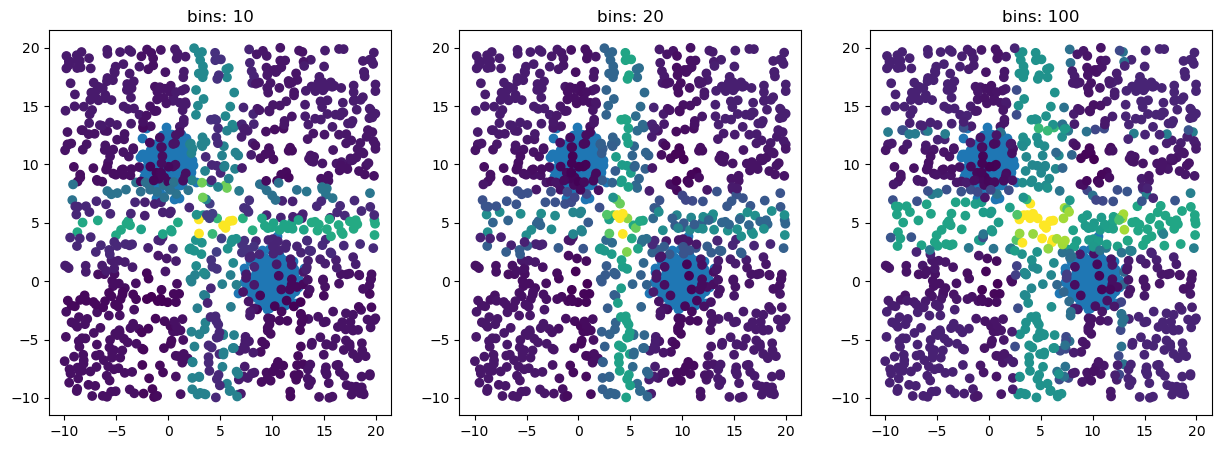

In [82]:
def compute_loda_scores(x, test_data, bins):
    loda_model = LODA(contamination=0.02, n_bins=bins)
    loda_model.fit(x)
    loda_scores = loda_model.decision_function(test_data)
    return loda_scores


bins = [10, 20, 100]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i in range(3):
    scores = compute_loda_scores(x, test_data, bins[i])

    axes[i].scatter(x[:, 0], x[:, 1])
    axes[i].scatter(test_data[:, 0], test_data[:, 1], c=scores, cmap='viridis')
    axes[i].set_title(f"bins: {bins[i]}")
    
plt.plot()



## 3D case

In [83]:
x, y = make_blobs(n_samples=1000, n_features=3, centers=[(0, 10, 0), (10, 0, 10)], random_state=42)
test_data = np.random.uniform(-10, 20, (1000, 3))


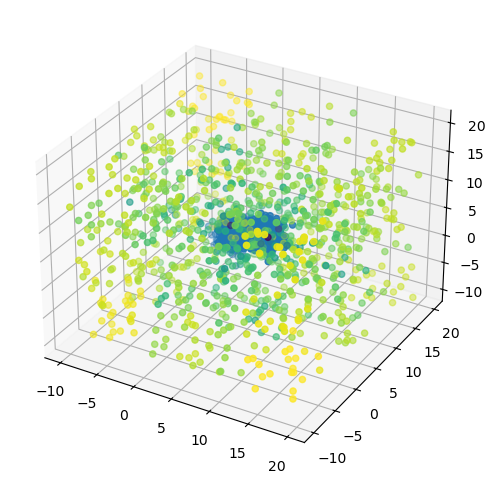

In [86]:
iforest_model = IForest(contamination=0.02)
iforest_model.fit(x)
iforest_scores = iforest_model.decision_function(test_data)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:,0], x[:,1], x[:,2])
ax.scatter(test_data[:,0], test_data[:,1], test_data[:,2], c=iforest_scores, cmap='viridis')
plt.show()

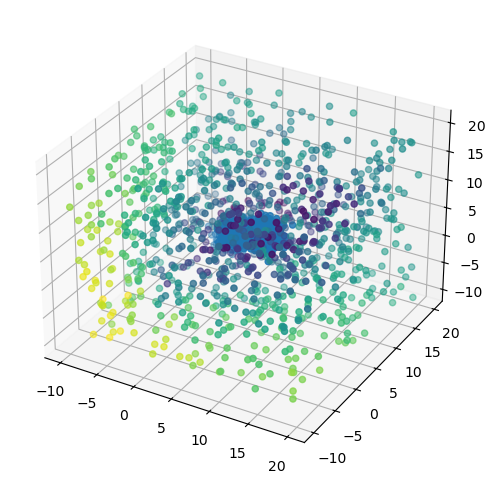

In [87]:
dif_model = DIF(contamination=0.02)
dif_model.fit(x)
dif_scores = dif_model.decision_function(test_data)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:,0], x[:,1], x[:,2])
ax.scatter(test_data[:,0], test_data[:,1], test_data[:,2], c=dif_scores, cmap='viridis')
plt.show()


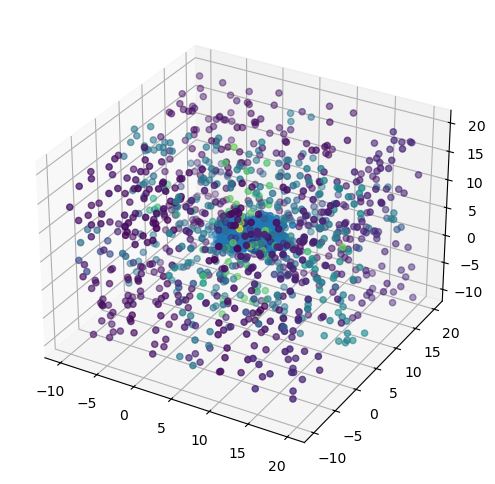

In [89]:
loda_model = LODA(contamination=0.02)
loda_model.fit(x)
loda_scores = loda_model.decision_function(test_data)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:,0], x[:,1], x[:,2])
ax.scatter(test_data[:,0], test_data[:,1], test_data[:,2], c=loda_scores, cmap='viridis')
plt.show()


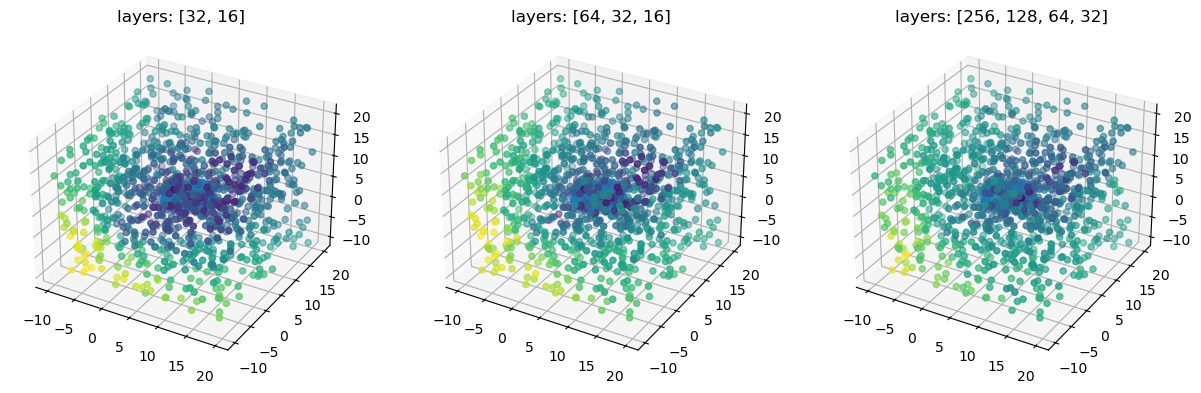

In [90]:
def compute_dif_scores(x, test_data, hidden_layers):
    dif_model = DIF(contamination=0.02, hidden_neurons=hidden_layers)
    dif_model.fit(x)
    dif_scores = dif_model.decision_function(test_data)
    return dif_scores


layers = [[32, 16], [64, 32, 16], [256, 128, 64, 32]]
fig = plt.figure(figsize=(15, 5))

for i in range(3):
    scores = compute_dif_scores(x, test_data, layers[i])
    
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    
    ax.scatter(x[:, 0], x[:, 1], x[:,2])
    ax.scatter(test_data[:, 0], test_data[:, 1],test_data[:,2], c=scores, cmap='viridis')
    ax.set_title(f"layers: {layers[i]}")
    
plt.show()

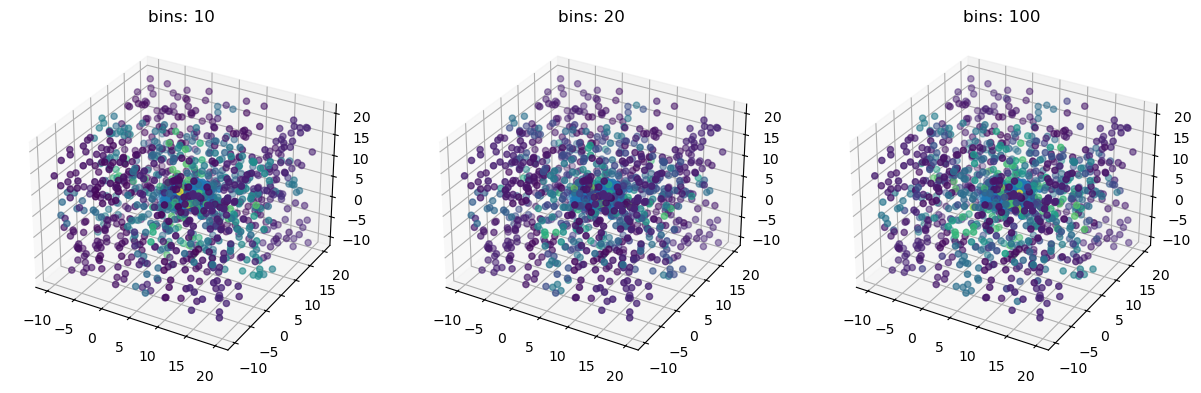

In [92]:
def compute_loda_scores(x, test_data, bins):
    loda_model = LODA(contamination=0.02, n_bins=bins)
    loda_model.fit(x)
    loda_scores = loda_model.decision_function(test_data)
    return loda_scores


bins = [10, 20, 100]
fig = plt.figure(figsize=(15, 5))

for i in range(3):
    scores = compute_loda_scores(x, test_data, bins[i])

    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    ax.scatter(x[:, 0], x[:, 1], x[:,2])
    ax.scatter(test_data[:, 0], test_data[:, 1], test_data[:,2], c=scores, cmap='viridis')
    ax.set_title(f"bins: {bins[i]}")
    
plt.show()

# Ex 3

In [114]:
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, ShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

In [99]:
data = loadmat("shuttle.mat")
x = data["X"]
y = data["y"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4)

In [101]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [117]:
splitter = ShuffleSplit(n_splits=10, test_size = 0.4)

ba_iforest = []
ba_dif = []
ba_loda = []

roc_auc_iforest = []
roc_auc_dif = []
roc_auc_loda = []


for i in splitter.split(x):
    x_train, y_train = np.array(x[i[0]]), y[i[0]]
    x_test, y_test = np.array(x[i[1]]), y[i[1]]

    iforest_model = IForest()
    dif_model = DIF()
    loda_model = LODA()
    
    iforest_model.fit(x_train)
    dif_model.fit(x_train)
    loda_model.fit(x_train)
    
    iforest_preds = iforest_model.predict(x_test)
    ba_iforest.append(balanced_accuracy_score(y_test, iforest_preds))
    roc_auc_iforest.append(roc_auc_score(y_test, iforest_model.predict_proba(x_test)[:,1]))

    dif_preds = dif_model.predict(x_test)
    ba_dif.append(balanced_accuracy_score(y_test, dif_preds))
    roc_auc_dif.append(roc_auc_score(y_test, dif_model.predict_proba(x_test)[:,1]))

    loda_preds = loda_model.predict(x_test)
    ba_loda.append(balanced_accuracy_score(y_test, loda_preds))
    roc_auc_loda.append(roc_auc_score(y_test, loda_model.predict_proba(x_test)[:,1]))


In [118]:
print(f"IForest model: balanced acc: {np.mean(ba_iforest)}, roc auc score: {np.mean(roc_auc_iforest)}")
print(f"DIF model: balanced acc: {np.mean(ba_dif)}, roc auc score: {np.mean(roc_auc_dif)}")
print(f"LODA model: balanced acc: {np.mean(ba_loda)}, roc auc score: {np.mean(roc_auc_loda)}")

IForest model: balanced acc: 0.9764060462651717, roc auc score: 0.996722729396665
DIF model: balanced acc: 0.501541525173069, roc auc score: 0.9633759923399143
LODA model: balanced acc: 0.5719715063907924, roc auc score: 0.47579750801840603
